# Session Learning Curve

**Goal**: Characterize how decision-making signatures evolve across visits using session-level behavioral and physiological features — rather than LOSO classification accuracy.

**Two analysis tracks**:

1. **Matched cohort design** — build 3-visit (N=11) and V1+V2 matched-pair (N=35) cohorts by tracking the same team × desktop-ID across visits. Equalized N is handled via bootstrap subsampling in `02_subject_repeat_analysis.ipynb`.

2. **Behavioral / physiological signatures as learning metrics** — per-session-per-subject values of:
   - `log_odds_invest`: logit(invest rate) — policy commitment
   - `ev_sensitivity`: Spearman ρ(outcome, ev_difference) — EV calibration
   - `ambiguity_aversion`: invest_rate(amb=0) − invest_rate(amb>0)
   - `choice_momentum`: Spearman ρ(prev_outcome, outcome)
   - `rt_mean`, `rt_cv`: decision speed and variability
   - `pupil_mean`, `pupil_cv`, `fixation_ratio`, `saccade_count`

   LMM: `signature ~ visit_number + (1|user_id)` on matched cohort, paired t-tests V1→V2.

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.special import logit
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features

RESULTS_DIR = Path('../../data/results/main/learning_curve')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TIMEFRAME = 'PRE'
RANDOM_STATE = 42

## 1. Load Data

In [2]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Restrict to the 80-subject EEG set
EEG_ACC_PATH = '../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv'
eeg_subjects = set(pd.read_csv(EEG_ACC_PATH)['subject_id'])
df = df[df['subject_id'].isin(eeg_subjects)].copy()

# Add visit info from corrected session_mapping
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']

df = df.merge(sm[['subject_id', 'visit_number', 'team', 'user_id']], on='subject_id', how='left')

print(f"Total trials: {len(df)}, subjects: {df['subject_id'].nunique()} (EEG set only)")
print("Trials per visit:")
print(df['visit_number'].value_counts().sort_index())
print(f"NaN visit: {df['visit_number'].isna().sum()} trials")

Total trials: 9618, subjects: 80 (EEG set only)
Trials per visit:
visit_number
1.0    4597
2.0    3704
3.0    1317
Name: count, dtype: int64
NaN visit: 0 trials


## 2. Build Matched Cohorts

- **3-visit cohort**: Teams 17, 21, 22, 24 — subjects with sessions at all three visits (same team × desktop ID)
- **V1+V2 pairs**: all teams with both V1 and V2 sessions

In [3]:
def get_subject_id(team, user_id, visit):
    row = sm[(sm['team'] == team) & (sm['user_id'] == user_id) & (sm['visit_number'] == visit)]
    return row['subject_id'].values[0] if len(row) else None

teams_v1 = set(sm[sm['visit_number'] == 1.0]['team'].dropna())
teams_v2 = set(sm[sm['visit_number'] == 2.0]['team'].dropna())
teams_v3 = set(sm[sm['visit_number'] == 3.0]['team'].dropna())

v12_teams = sorted(teams_v1 & teams_v2)
three_visit_teams = sorted(teams_v1 & teams_v2 & teams_v3)

# 3-visit cohort
records_3v = []
for team in three_visit_teams:
    uids = (set(sm[(sm['team']==team) & (sm['visit_number']==1.0)]['user_id']) &
            set(sm[(sm['team']==team) & (sm['visit_number']==2.0)]['user_id']) &
            set(sm[(sm['team']==team) & (sm['visit_number']==3.0)]['user_id']))
    for uid in uids:
        records_3v.append({'team': team, 'user_id': uid,
                           'subj_v1': get_subject_id(team, uid, 1.0),
                           'subj_v2': get_subject_id(team, uid, 2.0),
                           'subj_v3': get_subject_id(team, uid, 3.0)})
cohort_3v = pd.DataFrame(records_3v)

# V1+V2 matched pairs
records_2v = []
for team in v12_teams:
    uids = (set(sm[(sm['team']==team) & (sm['visit_number']==1.0)]['user_id']) &
            set(sm[(sm['team']==team) & (sm['visit_number']==2.0)]['user_id']))
    for uid in uids:
        records_2v.append({'team': team, 'user_id': uid,
                           'subj_v1': get_subject_id(team, uid, 1.0),
                           'subj_v2': get_subject_id(team, uid, 2.0)})
cohort_2v = pd.DataFrame(records_2v)

print(f"3-visit cohort: {len(cohort_3v)} subjects (Teams: {three_visit_teams})")
print(f"V1+V2 matched pairs: {len(cohort_2v)} subjects")
print(cohort_3v.to_string(index=False))

3-visit cohort: 11 subjects (Teams: ['Team 17', 'Team 21', 'Team 22', 'Team 24'])
V1+V2 matched pairs: 35 subjects
   team user_id           subj_v1           subj_v2           subj_v3
Team 17 9M4VCHG 0824_1000_9M4VCHG 0825_1000_9M4VCHG 0826_1000_9M4VCHG
Team 17 539136F 0824_1000_539136F 0825_1000_539136F 0826_1000_539136F
Team 21 9M4VCHG 0830_1300_9M4VCHG 0831_1300_9M4VCHG 0901_1300_9M4VCHG
Team 21 539136F 0830_1300_539136F 0831_1300_539136F 0901_1300_539136F
Team 21 U9TEJGM 0830_1300_U9TEJGM 0831_1300_U9TEJGM 0901_1300_U9TEJGM
Team 22 9M4VCHG 0915_1000_9M4VCHG 0917_1030_9M4VCHG 0924_1000_9M4VCHG
Team 22 539136F 0915_1000_539136F 0917_1030_539136F 0924_1000_539136F
Team 22 U9TEJGM 0915_1000_U9TEJGM 0917_1030_U9TEJGM 0924_1000_U9TEJGM
Team 24 9M4VCHG 0920_1600_9M4VCHG 0923_1600_9M4VCHG 0924_1600_9M4VCHG
Team 24 539136F 0920_1600_539136F 0923_1600_539136F 0924_1600_539136F
Team 24 U9TEJGM 0920_1600_U9TEJGM 0923_1600_U9TEJGM 0924_1600_U9TEJGM


## 3. Compute Per-Session Behavioral Signatures

In [4]:
def safe_logit(p, eps=1e-3):
    p = np.clip(p, eps, 1 - eps)
    return float(np.log(p / (1 - p)))


def session_signatures(trials):
    if len(trials) < 10:
        return None
    out = {}
    out['n_trials'] = len(trials)

    invest_rate = trials['outcome'].mean()
    out['invest_rate'] = invest_rate
    out['log_odds_invest'] = safe_logit(invest_rate)

    ev = trials['ev_difference'].values
    y = trials['outcome'].values
    out['ev_sensitivity'] = stats.spearmanr(ev, y, nan_policy='omit').statistic

    amb0 = trials[trials['ambiguity'] == 0]['outcome'].mean()
    ambpos = trials[trials['ambiguity'] > 0]['outcome'].mean()
    out['ambiguity_aversion'] = (amb0 - ambpos) if (not np.isnan(amb0) and not np.isnan(ambpos)) else np.nan

    prev = trials['prev_outcome'].values
    out['choice_momentum'] = stats.spearmanr(prev, y, nan_policy='omit').statistic

    rt = trials['decision_time'].values
    out['rt_mean'] = np.nanmean(rt)
    out['rt_cv'] = np.nanstd(rt) / np.nanmean(rt) if np.nanmean(rt) > 0 else np.nan

    out['pupil_mean'] = trials['pupil_mean_pre'].mean()
    out['pupil_cv'] = trials['pupil_cv_pre'].mean()
    out['fixation_ratio'] = trials['fixation_ratio'].mean()
    out['saccade_count'] = trials['saccade_count'].mean()

    return out


def build_signature_df(df_trials):
    rows = []
    for subj, grp in df_trials.groupby('subject_id'):
        meta = grp[['visit_number', 'team', 'user_id']].iloc[0]
        sigs = session_signatures(grp)
        if sigs is None:
            continue
        rows.append({'subject_id': subj,
                     'visit_number': meta['visit_number'],
                     'team': meta['team'],
                     'user_id': meta['user_id'],
                     **sigs})
    return pd.DataFrame(rows)


sig_df = build_signature_df(df[df['visit_number'].notna()])
print(f"Signature rows: {len(sig_df)} (subjects × visit)")
sig_df.groupby('visit_number')[['invest_rate', 'ev_sensitivity', 'ambiguity_aversion',
                                      'choice_momentum', 'rt_mean', 'pupil_mean']].mean().round(3)

Signature rows: 80 (subjects × visit)


,invest_rate,ev_sensitivity,ambiguity_aversion,choice_momentum,rt_mean,pupil_mean
visit_number,,,,,,
1.0,0.612,0.093,0.334,-0.002,2.596,0.403
2.0,0.692,0.115,0.156,-0.005,2.198,0.402
3.0,0.683,0.221,0.136,-0.008,1.920,0.449


## 4. 3-Visit Cohort Signatures

In [5]:
sig_cols = ['invest_rate', 'log_odds_invest', 'ev_sensitivity', 'ambiguity_aversion',
            'choice_momentum', 'rt_mean', 'rt_cv', 'pupil_mean', 'pupil_cv',
            'fixation_ratio', 'saccade_count']

subjs_3v = pd.concat([
    cohort_3v['subj_v1'], cohort_3v['subj_v2'], cohort_3v['subj_v3']
]).dropna().unique()
sig_3v = sig_df[sig_df['subject_id'].isin(subjs_3v)].copy()

print("3-visit cohort — signatures per visit:")
sig_3v.groupby('visit_number')[['invest_rate', 'ev_sensitivity', 'ambiguity_aversion',
                                      'choice_momentum', 'rt_mean', 'pupil_mean']].mean().round(3)

3-visit cohort — signatures per visit:


,invest_rate,ev_sensitivity,ambiguity_aversion,choice_momentum,rt_mean,pupil_mean
visit_number,,,,,,
1.0,0.606,0.159,0.408,-0.021,2.545,0.431
2.0,0.704,0.148,0.260,0.009,1.992,0.388
3.0,0.683,0.221,0.136,-0.008,1.920,0.449


## 5. LMM: Signature ~ Visit Number

In [6]:
all_matched_subjs = pd.concat([
    cohort_2v['subj_v1'], cohort_2v['subj_v2'],
    cohort_3v['subj_v1'], cohort_3v['subj_v2'], cohort_3v['subj_v3']
]).dropna().unique()

lmm_df = sig_df[sig_df['subject_id'].isin(all_matched_subjs)].copy()
lmm_df['visit'] = lmm_df['visit_number'].astype(float)

print(f"LMM dataset: {len(lmm_df)} rows, {lmm_df['subject_id'].nunique()} subjects")
print(f"Visit distribution: {lmm_df['visit'].value_counts().sort_index().to_dict()}")

lmm_results = []
for sig in sig_cols:
    tmp = lmm_df[['visit', 'user_id', 'team', sig]].dropna()
    if len(tmp) < 10:
        continue
    try:
        model = smf.mixedlm(f'{sig} ~ visit', tmp, groups=tmp['user_id'], re_formula='~1')
        res = model.fit(reml=True, method='lbfgs', disp=False)
        lmm_results.append({
            'signature': sig,
            'beta_visit': res.params.get('visit', np.nan),
            'se': res.bse.get('visit', np.nan),
            'z': res.tvalues.get('visit', np.nan),
            'p': res.pvalues.get('visit', np.nan),
            'n': len(tmp),
        })
    except Exception as e:
        print(f"  {sig}: {e}")

lmm_res_df = pd.DataFrame(lmm_results).sort_values('p')
lmm_res_df['sig'] = lmm_res_df['p'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '†' if p<.1 else '')
print("\nLMM results (visit slope):")
print(lmm_res_df.to_string(index=False))

LMM dataset: 63 rows, 63 subjects
Visit distribution: {1.0: 23, 2.0: 29, 3.0: 11}



LMM results (visit slope):
         signature  beta_visit       se         z        p  n sig
           rt_mean   -0.342867 0.075764 -4.525470 0.000006 63 ***
ambiguity_aversion   -0.128734 0.038461 -3.347137 0.000817 63 ***
   log_odds_invest    0.454311 0.333290  1.363110 0.172848 63    
    fixation_ratio   -0.002291 0.001734 -1.321331 0.186391 63    
       invest_rate    0.044614 0.035267  1.265053 0.205852 63    
             rt_cv   -0.007516 0.008345 -0.900625 0.367788 63    
          pupil_cv   -0.318353 0.514718 -0.618499 0.536247 63    
    ev_sensitivity    0.030038 0.049776  0.603458 0.546204 59    
        pupil_mean    0.016643 0.028419  0.585632 0.558123 63    
     saccade_count    0.121038 0.224106  0.540090 0.589135 63    
   choice_momentum    0.002673 0.024090  0.110966 0.911644 59    


## 6. Trajectories: 3-Visit Cohort

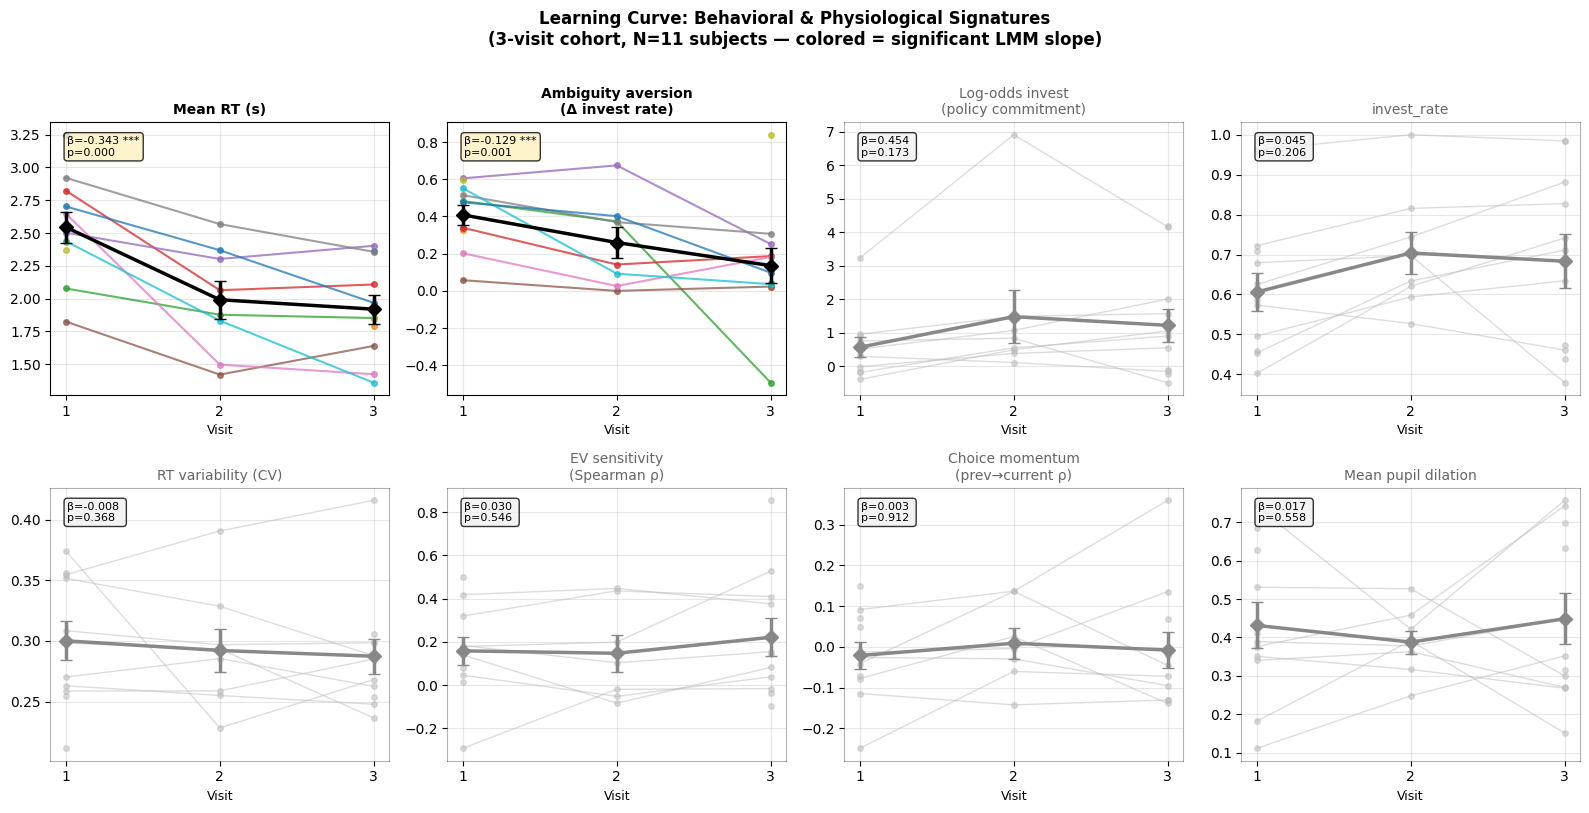

Saved.


In [7]:
sig_labels = {
    'log_odds_invest': 'Log-odds invest\n(policy commitment)',
    'ev_sensitivity': 'EV sensitivity\n(Spearman ρ)',
    'ambiguity_aversion': 'Ambiguity aversion\n(Δ invest rate)',
    'choice_momentum': 'Choice momentum\n(prev→current ρ)',
    'rt_mean': 'Mean RT (s)',
    'rt_cv': 'RT variability (CV)',
    'pupil_mean': 'Mean pupil dilation',
    'fixation_ratio': 'Fixation ratio',
}

plot_sigs = ['rt_mean', 'ambiguity_aversion', 'log_odds_invest', 'invest_rate',
             'rt_cv', 'ev_sensitivity', 'choice_momentum', 'pupil_mean']

# Assign one color per subject (consistent across all panels)
subject_ids = cohort_3v.index.tolist()
subj_palette = sns.color_palette('tab10', n_colors=len(cohort_3v))
subj_colors = {i: subj_palette[i] for i in range(len(cohort_3v))}

# Significance from LMM (p < 0.05)
sig_lmm_set = set(lmm_res_df[lmm_res_df['p'] < 0.05]['signature'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, sig in zip(axes, plot_sigs):
    is_sig = sig in sig_lmm_set

    for i, (_, row) in enumerate(cohort_3v.iterrows()):
        vals = []
        for col in ['subj_v1', 'subj_v2', 'subj_v3']:
            match = sig_3v[sig_3v['subject_id'] == row[col]]
            vals.append(match[sig].values[0] if len(match) else np.nan)

        if is_sig:
            color = subj_colors[i]
            alpha, lw, zorder = 0.75, 1.5, 3
        else:
            color = '#bbbbbb'
            alpha, lw, zorder = 0.5, 1.0, 2

        ax.plot([1, 2, 3], vals, color=color, alpha=alpha,
                linewidth=lw, zorder=zorder, marker='o', markersize=4)

    # Group mean ± SE on top
    grp = sig_3v.groupby('visit_number')[sig].agg(['mean', 'sem'])
    mean_color = 'black' if is_sig else '#888888'
    ax.errorbar(grp.index, grp['mean'], yerr=grp['sem'],
                color=mean_color, linewidth=2.5, capsize=4,
                zorder=6, marker='D', markersize=7)

    # LMM annotation
    row_res = lmm_res_df[lmm_res_df['signature'] == sig]
    if len(row_res):
        p = row_res['p'].values[0]
        b = row_res['beta_visit'].values[0]
        star = row_res['sig'].values[0]
        ax.text(0.05, 0.95, f'β={b:.3f} {star}\np={p:.3f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round',
                          facecolor='#fff0c0' if is_sig else '#f0f0f0',
                          alpha=0.8))

    title = sig_labels.get(sig, sig)
    ax.set_title(title, fontsize=10,
                 fontweight='bold' if is_sig else 'normal',
                 color='black' if is_sig else '#666666')
    ax.set_xlabel('Visit', fontsize=9)
    ax.set_xticks([1, 2, 3])
    ax.grid(True, alpha=0.3)
    if not is_sig:
        ax.spines[['top','right','left','bottom']].set_alpha(0.3)

fig.suptitle('Learning Curve: Behavioral & Physiological Signatures\n'
             '(3-visit cohort, N=11 subjects — colored = significant LMM slope)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'learning_curve_3visit_trajectories_{TIMEFRAME}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 7. Paired t-tests: V1 vs V2 (matched pairs)

In [8]:
paired_rows = []
for _, row in cohort_2v.iterrows():
    s1 = sig_df[sig_df['subject_id'] == row['subj_v1']]
    s2 = sig_df[sig_df['subject_id'] == row['subj_v2']]
    if len(s1) == 0 or len(s2) == 0:
        continue
    r = {'team': row['team'], 'user_id': row['user_id']}
    for sig in sig_cols:
        r[f'{sig}_v1'] = s1[sig].values[0]
        r[f'{sig}_v2'] = s2[sig].values[0]
        r[f'{sig}_delta'] = s2[sig].values[0] - s1[sig].values[0]
    paired_rows.append(r)

paired_df = pd.DataFrame(paired_rows)
print(f"Paired V1-V2 subjects: {len(paired_df)}")

paired_tests = []
for sig in sig_cols:
    v1v = paired_df[f'{sig}_v1'].dropna()
    v2v = paired_df[f'{sig}_v2'].dropna()
    common_idx = v1v.index.intersection(v2v.index)
    if len(common_idx) < 5:
        continue
    t, p = stats.ttest_rel(v1v[common_idx], v2v[common_idx])
    delta_mean = (v2v[common_idx] - v1v[common_idx]).mean()
    delta_se = (v2v[common_idx] - v1v[common_idx]).sem()
    paired_tests.append({'signature': sig, 'delta_mean': delta_mean, 'delta_se': delta_se,
                         't': t, 'p': p, 'n': len(common_idx)})

paired_res = pd.DataFrame(paired_tests).sort_values('p')
paired_res['sig'] = paired_res['p'].apply(lambda p: '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '†' if p<.1 else '')
print("\nPaired t-tests (V2 − V1):")
print(paired_res.to_string(index=False))

Paired V1-V2 subjects: 19

Paired t-tests (V2 − V1):
         signature  delta_mean  delta_se         t        p  n sig
           rt_mean   -0.445414  0.095258  4.675866 0.000188 19 ***
ambiguity_aversion   -0.177165  0.045648  3.881073 0.001095 19  **
   log_odds_invest    1.476000  0.544478 -2.710853 0.014318 19   *
       invest_rate    0.106326  0.040646 -2.615893 0.017504 19   *
             rt_cv   -0.022681  0.010771  2.105684 0.049535 19   *
   choice_momentum    0.075919  0.039857 -1.904789 0.077559 15   †
     saccade_count   -0.229572  0.231623  0.991143 0.334753 19    
          pupil_cv    0.781416  0.840222 -0.930011 0.364671 19    
    ev_sensitivity    0.028099  0.054512 -0.515467 0.614270 15    
    fixation_ratio    0.000480  0.001018 -0.471644 0.642847 19    
        pupil_mean    0.011992  0.034965 -0.342979 0.735587 19    


## 8. Forest Plots: Paired Δ and LMM Slopes

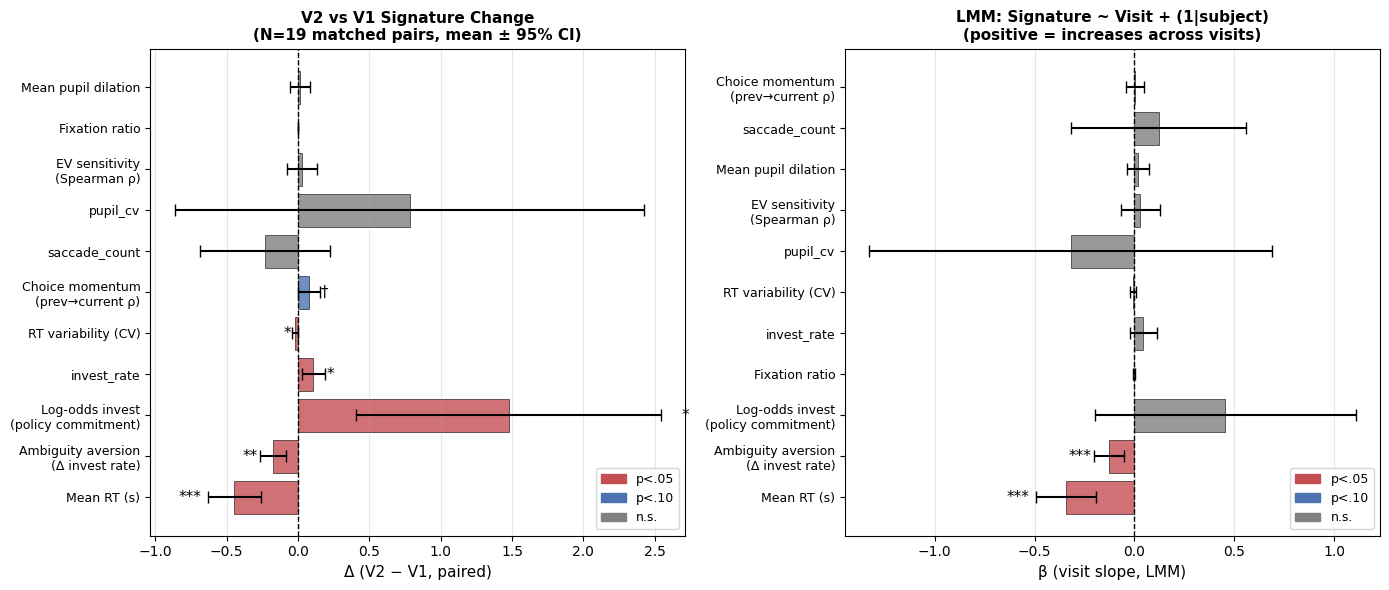

Saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: paired V2-V1 delta
ax = axes[0]
y_pos = np.arange(len(paired_res))
colors_p = ['#C44E52' if p < 0.05 else '#4C72B0' if p < 0.1 else 'gray'
            for p in paired_res['p']]
ax.barh(y_pos, paired_res['delta_mean'], xerr=1.96 * paired_res['delta_se'],
        color=colors_p, alpha=0.8, edgecolor='black', linewidth=0.5, capsize=4)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
for i, (_, r) in enumerate(paired_res.iterrows()):
    if r['sig']:
        x = r['delta_mean'] + np.sign(r['delta_mean']) * (1.96 * r['delta_se'] + abs(r['delta_mean']) * 0.1)
        ax.text(x, i, r['sig'], va='center', fontsize=11,
                ha='left' if r['delta_mean'] >= 0 else 'right')
ax.set_yticks(y_pos)
ax.set_yticklabels([sig_labels.get(s, s) for s in paired_res['signature']], fontsize=9)
ax.set_xlabel('Δ (V2 − V1, paired)', fontsize=11)
ax.set_title(f'V2 vs V1 Signature Change\n(N={len(paired_df)} matched pairs, mean ± 95% CI)',
             fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='p<.05'), Patch(color='#4C72B0', label='p<.10'),
                   Patch(color='gray', label='n.s.')], loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel B: LMM visit slope
ax = axes[1]
y_pos = np.arange(len(lmm_res_df))
colors_l = ['#C44E52' if p < 0.05 else '#4C72B0' if p < 0.1 else 'gray'
            for p in lmm_res_df['p']]
ax.barh(y_pos, lmm_res_df['beta_visit'], xerr=1.96 * lmm_res_df['se'],
        color=colors_l, alpha=0.8, edgecolor='black', linewidth=0.5, capsize=4)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
for i, (_, r) in enumerate(lmm_res_df.iterrows()):
    if r['sig']:
        x = r['beta_visit'] + np.sign(r['beta_visit']) * (1.96 * r['se'] + abs(r['beta_visit']) * 0.1)
        ax.text(x, i, r['sig'], va='center', fontsize=11,
                ha='left' if r['beta_visit'] >= 0 else 'right')
ax.set_yticks(y_pos)
ax.set_yticklabels([sig_labels.get(s, s) for s in lmm_res_df['signature']], fontsize=9)
ax.set_xlabel('β (visit slope, LMM)', fontsize=11)
ax.set_title('LMM: Signature ~ Visit + (1|subject)\n(positive = increases across visits)',
             fontsize=11, fontweight='bold')
ax.legend(handles=[Patch(color='#C44E52', label='p<.05'), Patch(color='#4C72B0', label='p<.10'),
                   Patch(color='gray', label='n.s.')], loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'learning_curve_forest_plots_{TIMEFRAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 9. Save Results

In [10]:
sig_df.to_csv(RESULTS_DIR / f'session_signatures_{TIMEFRAME}.csv', index=False)
lmm_res_df.to_csv(RESULTS_DIR / f'lmm_visit_slopes_{TIMEFRAME}.csv', index=False)
paired_res.to_csv(RESULTS_DIR / f'paired_v1v2_tests_{TIMEFRAME}.csv', index=False)
sig_3v.to_csv(RESULTS_DIR / f'signatures_3visit_cohort_{TIMEFRAME}.csv', index=False)

print(f"All results saved to {RESULTS_DIR}")
print("\n=== SUMMARY ===")
print(f"Signatures with significant visit slope (LMM p<.05):")
sig_lmm = lmm_res_df[lmm_res_df['p'] < 0.05]
print(sig_lmm[['signature', 'beta_visit', 'p', 'sig']].to_string(index=False) if len(sig_lmm) else "  None")
print(f"\nSignatures with significant V2-V1 change (paired t p<.05):")
sig_paired = paired_res[paired_res['p'] < 0.05]
print(sig_paired[['signature', 'delta_mean', 'p', 'sig']].to_string(index=False) if len(sig_paired) else "  None")

All results saved to ../../data/results/main/learning_curve

=== SUMMARY ===
Signatures with significant visit slope (LMM p<.05):
         signature  beta_visit        p sig
           rt_mean   -0.342867 0.000006 ***
ambiguity_aversion   -0.128734 0.000817 ***

Signatures with significant V2-V1 change (paired t p<.05):
         signature  delta_mean        p sig
           rt_mean   -0.445414 0.000188 ***
ambiguity_aversion   -0.177165 0.001095  **
   log_odds_invest    1.476000 0.014318   *
       invest_rate    0.106326 0.017504   *
             rt_cv   -0.022681 0.049535   *
